In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys

sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis/py_functions')

from scipy.stats import norm
from tkinter import *
import scipy
from scipy import signal

import platform
from glob import glob
from scipy.spatial import distance
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
import statsmodels.api as sm
import statsmodels.formula.api as smf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

#
from scipy.signal import hilbert, butter, filtfilt
import scipy.stats as stats
from tqdm.notebook import trange, tqdm
import load_summary as ls
cwd             = os.getcwd()

##all 
cond_vals   = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159','#594157', "#F1BF98","#8FB996"]
dist_groups = np.array([[0,15],[15,30],[30,5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab

sys.path.append('T:\\EL_experiment\Codes\CCEP_human\Python_Analysis\py_functions')
sys.path.append('X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram')
sys.path.append('T:\\EL_experiment\Codes\\UBELIX_EvM\\NMF\\functions')
path_connectogram = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram'
from main_script import ConnectogramPlotter
cwp = os.getcwd()

In [2]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [98]:
regions_all
region_col

array(['Dorsofrontal', 'Orbitofrontal', 'Insula', 'Central',
       'Basotemporal', 'Hippocampus', 'Amygdala', 'Laterotemporal',
       'Cingular', 'Parietal', 'Occipital'], dtype=object)

In [3]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

In [4]:
def adding_destrieux(data_con, pair=1, area='Destrieux'):
    # area == 'Region' or 'Area'
    CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
    atlas = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')
    if pair:
        for subregion in np.unique(data_con[['StimA', 'ChanA']]):
            region = atlas.loc[atlas.Abbreviation == subregion, area].values
            if len(region) > 0:
                data_con.loc[data_con.StimA == subregion, 'StimR'] = region[0]
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = region[0]
            else:
                print(subregion)
                data_con.loc[data_con.StimA == subregion, 'StimR'] = 'U'
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = 'U'
    else:
        for subregion in np.unique(data_con[['ChanA']]):
            region = atlas.loc[atlas.Abbreviation == subregion, area].values
            if len(region) > 0:
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = region[0]
            else:
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = 'U'
    return data_con

In [5]:

#import BM_across_plots as plotting

cwd = os.getcwd()

##all
cond_vals = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159', '#594157', "#F1BF98", "#8FB996"]
dist_groups = np.array([[0, 15], [15, 30], [30, 5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path = 'X:\\4 e-Lab\\'  # y:\\eLab

##
subjs = ["EL010", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]


In [6]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
atlas = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')


In [7]:
con_all = ls.get_connections(subjs, sub_path)
#con_all_ss = ls.get_connections_sleep(subjs, sub_path, ['Wake'])
con_all.loc[(con_all.True_peak == 0), 'Sig'] =0
con_all.loc[(con_all.Sig >0), 'Sig'] =1
con_all = con_all[(con_all.Sig>=0)].reset_index(drop=True)
data_mean = adding_destrieux(con_all[['Subj','Stim', 'Chan', 'Sig', 'd', 'StimA', 'ChanA','Hemi']], pair=1, area='Destrieux')
data_mean = data_mean.groupby(['Hemi','StimR', 'ChanR'], as_index=False)['Sig'].mean()

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\pandas\core\indexing.py:1599: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = infer_fill_value(value)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


Unknown


In [8]:
import gzip

# Function to read the parcel names into a list.
def read_parcel_names(file_path):
    with open(file_path, 'r') as f:
        parcels = f.read().splitlines()
    return parcels

# Function to read the gzipped matrix file into a DataFrame.
# Function to load the matrix data from a .txt.gz file
def load_matrix(matrix_file_path, headers):
    # Initialize a list to hold the matrix rows
    matrix_data = []
    
    # Open the gzipped text file
    with gzip.open(matrix_file_path, 'rt') as f:
        for line in f:
            # Skip lines that start with '#'
            if not line.startswith("#"):
                # Split the line by space and convert to floats
                row_data = [float(i) if i != 'nan' else np.nan for i in line.split()]
                matrix_data.append(row_data)
    
    # Create a DataFrame from the matrix_data list
    matrix_df = pd.DataFrame(matrix_data)
    # Set the parcel names as the row and column headers.
    matrix_df.columns = headers
    matrix_df.index = headers
    return matrix_df


In [34]:
# File paths - replace these with your actual file paths.
parcel_names_file_path = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\F_tracts\Destrieux.txt'
matrix_file_path = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\F_tracts\probability.txt.gz'

# Read the parcel names and matrix.
parcel_names = read_parcel_names(parcel_names_file_path)
matrix_ftract_P = load_matrix(matrix_file_path, parcel_names)
matrix_file_path = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\F_tracts\onset_delay__median.txt.gz'
matrix_ftract_delay = load_matrix(matrix_file_path, parcel_names)

In [55]:
hemi_sel ='L'
# Clean the parcel names according to your specifications

cleaned_parcel_names = []
if hemi_sel =='L':
    for name in parcel_names:
        if name.startswith('ctx_lh_'):
            cleaned_name =name.replace('ctx_lh_', '')  # Keep only the part after the last underscore
        elif name.startswith('Left-'):
            cleaned_name = name.replace('Left-', '')  # Keep only the part after the last underscore
        elif name.startswith('ctx_rh_'):
            cleaned_name ='R' # name.replace('ctx_rh_', '')  # Keep only the part after the last underscore
        elif name.startswith('Right-'):
            cleaned_name = 'R' # name.replace('Right-', '')  # Keep only the part after the last underscore
        else:
            cleaned_name = name  # If it doesn't match the above, keep the original name
        cleaned_parcel_names.append(cleaned_name)
elif hemi_sel =='R':
    for name in parcel_names:
        if name.startswith('ctx_rh_'):
            cleaned_name =name.replace('ctx_rh_', '')  # Keep only the part after the last underscore
        elif name.startswith('Right-'):
            cleaned_name = name.replace('Right-', '')  # Keep only the part after the last underscore
        elif name.startswith('ctx_lh_'):
            cleaned_name ='l' # name.replace('ctx_rh_', '')  # Keep only the part after the last underscore
        elif name.startswith('Left-'):
            cleaned_name = 'l' # name.replace('Right-', '')  # Keep only the part after the last underscore
        else:
            cleaned_name = name  # If it doesn't match the above, keep the original name
        cleaned_parcel_names.append(cleaned_name)
else:
    for name in parcel_names:
        if name.startswith('ctx_rh_'):
            cleaned_name =name.replace('ctx_rh_', '')  # Keep only the part after the last underscore
        elif name.startswith('Right-'):
            cleaned_name = name.replace('Right-', '')  # Keep only the part after the last underscore
        elif name.startswith('ctx_lh_'):
            cleaned_name =name.replace('ctx_lh_', '')  # Keep only the part after the last underscore
        elif name.startswith('Left-'):
            cleaned_name = name.replace('Left-', '')  # Keep only the part after the last underscore
        else:
            cleaned_name = name  # If it doesn't match the above, keep the original name
        cleaned_parcel_names.append(cleaned_name)

In [32]:
matrix_ftract = load_matrix(matrix_file_path, cleaned_parcel_names)
matrix_long_df = matrix_ftract.reset_index().melt(id_vars=['index'], var_name='ChanR', value_name='P')
matrix_long_df.rename(columns={'index': 'StimR'}, inplace=True)
matrix_long_df = matrix_long_df.groupby(['StimR', 'ChanR'], as_index=False)['P'].mean()

In [25]:
matrix_ftract = load_matrix(matrix_file_path, cleaned_parcel_names)
matrix_long_df = matrix_ftract.reset_index().melt(id_vars=['index'], var_name='ChanR', value_name='P')

In [13]:
df_merged = pd.merge(data_mean[data_mean.Hemi==hemi_sel], matrix_long_df, on=['StimR', 'ChanR'], how='left')

In [14]:
df_merged = df_merged[~np.isnan(df_merged.P)].reset_index(drop=True)

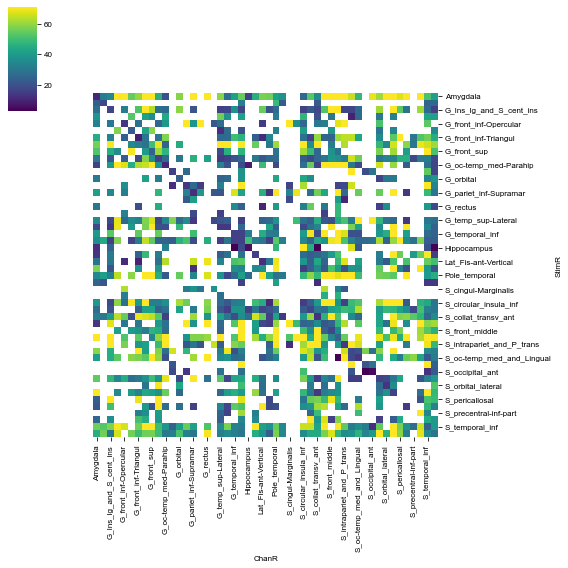

In [16]:
g = sns.clustermap(matrix_onset, cmap='viridis',
                   row_cluster=False, col_cluster=False,
                   figsize=(8,8), vmin = 3, vmax = np.nanpercentile(matrix_onset.values,90))

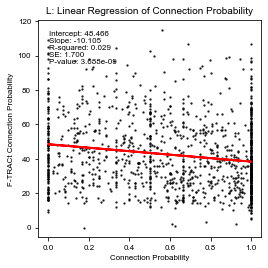

In [17]:


# Use your merged dataframe
# df_merged = ...

# Perform linear regression
X = df_merged[['Sig']].values.reshape(-1, 1)  # Independent variable
y = df_merged['P'].values  # Dependent variable

# Create linear regression object
regression = LinearRegression()
regression.fit(X, y)

# Make predictions using the regression object
y_pred = regression.predict(X)

plt.figure(figsize=(4,4))
# Scatterplot of the data
plt.scatter(X, y, color='k',s = 2, label='Data', alpha =.7)

# Line of best fit
plt.plot(X, y_pred, color='red', linewidth=2, label='Fit')

# Calculate regression details
slope = regression.coef_[0]
intercept = regression.intercept_
r_value = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
std_err = np.sqrt(mse)

# Use scipy to calculate the p-value
slope, intercept, r_value, p_value, std_err = stats.linregress(df_merged['Sig'], df_merged['P'])

# Add regression details to plot
text_str = f'Intercept: {intercept:.3f}\nSlope: {slope:.3f}\nR-squared: {r_value**2:.3f}\nSE: {std_err:.3f}\nP-value: {p_value:.3e}'
plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')

# Additional plot settings
plt.xlabel('Connection Probability')
plt.ylabel('F-TRACt Connection Probability')
plt.title(hemi_sel+': Linear Regression of Connection Probability')
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\F_tracts\probability_fit.svg')
plt.show()


## Unsupervised clustering

In [76]:
all_destrieux = np.unique(all_region.Destrieux.to_list())

In [77]:
rem_labels = ['Cerebral-White-Matter','Putamen','Necrosis','Outside','Pallidum','LV','Unknown', 'White-Matter','hypointensities','nan', 'out']
all_destrieux = [label for label in all_destrieux if label not in rem_labels]

In [87]:
matrix_ftract = load_matrix(matrix_file_path, cleaned_parcel_names)
matrix_long_df = matrix_ftract.reset_index().melt(id_vars=['index'], var_name='ChanR', value_name='onset')
matrix_long_df.rename(columns={'index': 'StimR'}, inplace=True)
matrix_long_df = matrix_long_df[np.isin(matrix_long_df.StimR, all_destrieux)&np.isin(matrix_long_df.ChanR, all_destrieux)].reset_index(drop=True)

In [121]:
matrix_df

ChanR,Amygdala,AnteroHippocampus,G_Ins_lg_and_S_cent_ins,G_and_S_cingul-Ant,G_and_S_cingul-Mid-Ant,G_and_S_cingul-Mid-Post,G_and_S_occipital_inf,G_cingul-Post-dorsal,G_cingul-Post-ventral,G_cuneus,...,S_parieto_occipital,S_pericallosal,S_postcentral,S_precentral-inf-part,S_precentral-sup-part,S_suborbital,S_subparietal,S_temporal_inf,S_temporal_sup,S_temporal_transverse
StimR,,,,,,,,,,,,,,,,,,,,,
Amygdala,10.156,31.641,35.000,75.586,66.898,NaN,83.000,76.562,79.492,NaN,...,92.188,67.172,78.500,91.000,NaN,72.656,61.469,51.172,41.406,70.215
AnteroHippocampus,23.000,17.969,32.809,80.000,88.281,62.000,67.000,64.844,54.102,NaN,...,59.961,54.000,29.688,25.781,51.000,66.398,64.500,24.652,26.000,34.000
G_Ins_lg_and_S_cent_ins,26.758,36.523,16.992,71.863,45.312,38.000,NaN,97.070,NaN,NaN,...,17.969,53.613,29.000,19.922,57.520,60.938,20.000,25.781,16.016,14.062
G_and_S_cingul-Ant,38.477,82.000,59.039,21.875,25.000,25.000,NaN,24.805,NaN,NaN,...,NaN,26.000,NaN,18.961,41.680,29.000,26.270,42.383,41.203,NaN
G_and_S_cingul-Mid-Ant,30.588,72.000,39.000,29.000,10.278,12.000,NaN,23.828,NaN,NaN,...,29.000,17.000,52.000,35.273,25.781,40.000,33.000,45.312,68.000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S_suborbital,25.000,73.316,36.000,29.844,46.500,40.500,NaN,42.586,NaN,NaN,...,NaN,44.500,NaN,NaN,NaN,12.000,NaN,43.848,39.453,NaN
S_subparietal,27.734,44.214,16.504,52.000,38.000,8.203,NaN,9.500,NaN,22.461,...,29.355,6.000,30.000,40.430,22.000,NaN,3.500,60.938,45.656,69.727
S_temporal_inf,56.000,52.637,57.500,70.000,NaN,NaN,24.000,68.750,NaN,NaN,...,64.500,56.516,37.000,27.344,NaN,65.576,45.621,24.000,39.453,32.250


In [89]:
matrix_long_df = matrix_long_df.groupby(['StimR', 'ChanR'], as_index=False)['onset'].mean()
matrix_df = matrix_long_df.pivot_table(index='StimR', columns='ChanR', values='onset')

In [ ]:
def adding_destrieux(data_con, pair=1, area='Destrieux'):
    # area == 'Region' or 'Area'
    CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
    atlas = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')
    if pair:
        for subregion in np.unique(data_con[['StimA', 'ChanA']]):
            region = atlas.loc[atlas.Abbreviation == subregion, area].values
            if len(region) > 0:
                data_con.loc[data_con.StimA == subregion, 'StimR'] = region[0]
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = region[0]
            else:
                print(subregion)
                data_con.loc[data_con.StimA == subregion, 'StimR'] = 'U'
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = 'U'
    else:
        for subregion in np.unique(data_con[['ChanA']]):
            region = atlas.loc[atlas.Abbreviation == subregion, area].values
            if len(region) > 0:
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = region[0]
            else:
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = 'U'
    return data_con

In [94]:
for dest in df_clusters.Label:
    region = atlas.loc[atlas.Destrieux == dest, 'Region'].values
    df_clusters.loc[df_clusters.Label == dest, 'Region'] = region[0]

In [1]:
# Assuming 'matrix_onset' is your DataFrame
matrix = matrix_df.values

# Create a graph
G = nx.from_numpy_matrix(matrix, create_using=nx.Graph)

# Replace NaN values in the graph with a very high value or remove edges
for u, v, d in list(G.edges(data=True)):
    if np.isnan(d['weight']):
        G.remove_edge(u, v)  # Option to remove edge
    else:
        G[u][v]['weight'] = 1 / d['weight']  # Inverting weight for distance interpretation

# Detect communities with a custom resolution parameter
# Default resolution is 1.0. Increase or decrease to change the granularity of the clustering.
resolution_value = 1.25  # Try different values to see how it affects the number of clusters
partition = community_louvain.best_partition(G, weight='weight', resolution=resolution_value)

# C

# Visualizing the graph with communities
pos = nx.spring_layout(G)  # positions for all nodes
cmap = plt.get_cmap('viridis')
for com in set(partition.values()):
    list_nodes = [nodes for nodes in partition.keys() if partition[nodes] == com]
    nx.draw_networkx_nodes(G, pos, list_nodes, node_size=2, node_color=cmap(com / max(partition.values())))
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.show()

# Create a DataFrame mapping labels to clusters
labels = matrix_df.columns  # Assuming headers are the labels
cluster_labels = [partition[i] for i in range(len(labels))]  # Mapping indices to cluster IDs
df_clusters = pd.DataFrame({'Label': labels, 'Cluster': cluster_labels})

NameError: name 'matrix_df' is not defined

In [141]:
for dest in df_clusters.Label:
    region = atlas.loc[atlas.Destrieux == dest, 'Region'].values
    df_clusters.loc[df_clusters.Label == dest, 'Region'] = region[0]

<AxesSubplot:xlabel='Cluster', ylabel='Count'>

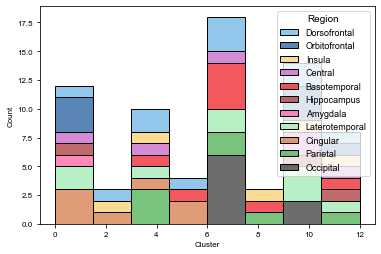

In [142]:
sns.histplot(data=df_clusters, x='Cluster', hue='Region', hue_order = regions_all, palette=region_col.tolist(), multiple='stack')

In [123]:
matrix_df = 1/matrix_df

In [124]:
matrix_df[np.isnan(matrix_df)] = 0

In [128]:
matrix_df

ChanR,Amygdala,AnteroHippocampus,G_Ins_lg_and_S_cent_ins,G_and_S_cingul-Ant,G_and_S_cingul-Mid-Ant,G_and_S_cingul-Mid-Post,G_and_S_occipital_inf,G_cingul-Post-dorsal,G_cingul-Post-ventral,G_cuneus,...,S_parieto_occipital,S_pericallosal,S_postcentral,S_precentral-inf-part,S_precentral-sup-part,S_suborbital,S_subparietal,S_temporal_inf,S_temporal_sup,S_temporal_transverse
StimR,,,,,,,,,,,,,,,,,,,,,
Amygdala,0.098464,0.031605,0.028571,0.013230,0.014948,0.000000,0.012048,0.013061,0.012580,0.000000,...,0.010847,0.014887,0.012739,0.010989,0.000000,0.013763,0.016268,0.019542,0.024151,0.014242
AnteroHippocampus,0.043478,0.055651,0.030479,0.012500,0.011327,0.016129,0.014925,0.015422,0.018484,0.000000,...,0.016678,0.018519,0.033684,0.038788,0.019608,0.015061,0.015504,0.040565,0.038462,0.029412
G_Ins_lg_and_S_cent_ins,0.037372,0.027380,0.058851,0.013915,0.022069,0.026316,0.000000,0.010302,0.000000,0.000000,...,0.055651,0.018652,0.034483,0.050196,0.017385,0.016410,0.050000,0.038788,0.062438,0.071114
G_and_S_cingul-Ant,0.025990,0.012195,0.016938,0.045714,0.040000,0.040000,0.000000,0.040314,0.000000,0.000000,...,0.000000,0.038462,0.000000,0.052740,0.023992,0.034483,0.038066,0.023594,0.024270,0.000000
G_and_S_cingul-Mid-Ant,0.032693,0.013889,0.025641,0.034483,0.097295,0.083333,0.000000,0.041967,0.000000,0.000000,...,0.034483,0.058824,0.019231,0.028350,0.038788,0.025000,0.030303,0.022069,0.014706,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S_suborbital,0.040000,0.013640,0.027778,0.033508,0.021505,0.024691,0.000000,0.023482,0.000000,0.000000,...,0.000000,0.022472,0.000000,0.000000,0.000000,0.083333,0.000000,0.022806,0.025347,0.000000
S_subparietal,0.036057,0.022617,0.060591,0.019231,0.026316,0.121907,0.000000,0.105263,0.000000,0.044522,...,0.034066,0.166667,0.033333,0.024734,0.045455,0.000000,0.285714,0.016410,0.021903,0.014342
S_temporal_inf,0.017857,0.018998,0.017391,0.014286,0.000000,0.000000,0.041667,0.014545,0.000000,0.000000,...,0.015504,0.017694,0.027027,0.036571,0.000000,0.015249,0.021920,0.041667,0.025347,0.031008


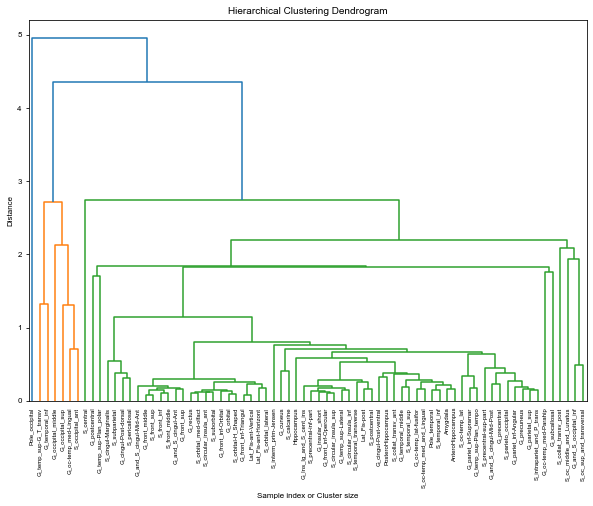

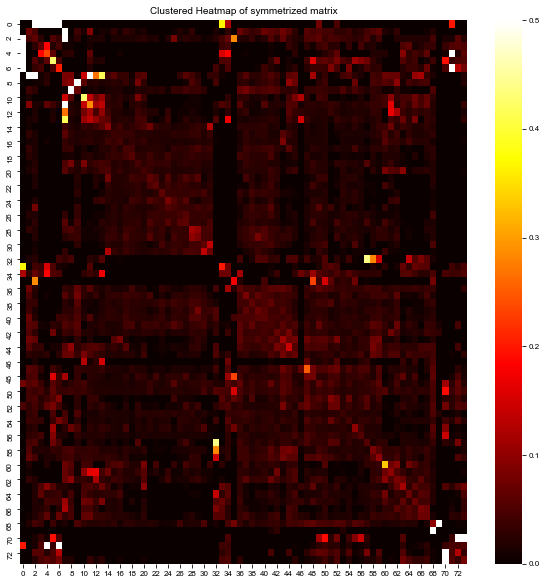

In [138]:
symmetric_matrix = (matrix_df.values + matrix_df.values.T) / 2
symmetric_matrix[np.isinf(symmetric_matrix)] = 0
# Step 2: Perform Hierarchical Clustering on the symmetrized matrix
linkage_matrix = linkage(symmetric_matrix, method='ward')

# Step 3: Plot Dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=matrix_df.columns.tolist())
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index or Cluster size')
plt.ylabel('Distance')
plt.show()

# Step 4: Reorder the matrix based on the clustering result for heatmap visualization
leaf_order = dendrogram(linkage_matrix, no_plot=True)['leaves']
symmetric_matrix_reordered = symmetric_matrix[np.ix_(leaf_order, leaf_order)]

# Step 5: Plotting the reordered matrix with a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(symmetric_matrix_reordered, cmap='hot', vmax = 0.5)
plt.title('Clustered Heatmap of symmetrized matrix')
plt.show()

In [125]:

# Step 2: Convert DataFrame to a condensed distance matrix required by linkage
dist_array = squareform(matrix_df)

# Step 3: Hierarchical Clustering
linkage_matrix = linkage(dist_array, 'ward')

# Step 3: Plot Dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=matrix_onset.columns.tolist())
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index or (Cluster size)')
plt.ylabel('Distance')
plt.show()

ValueError: Distance matrix 'X' must be symmetric.